In [1]:
%pip install clouddrift cartopy


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
## imports

import clouddrift as cd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scipy.stats import binned_statistic_2d
import gc

In [28]:
ds = cd.datasets.gdp1h()

In [4]:
ds

<xarray.Dataset> Size: 16GB
Dimensions:                (traj: 19396, obs: 197214787)
Coordinates:
    id                     (traj) int64 155kB ...
    time                   (obs) datetime64[ns] 2GB ...
Dimensions without coordinates: traj, obs
Data variables: (12/58)
    BuoyTypeManufacturer   (traj) |S20 388kB ...
    BuoyTypeSensorArray    (traj) |S20 388kB ...
    CurrentProgram         (traj) float64 155kB ...
    DeployingCountry       (traj) |S20 388kB ...
    DeployingShip          (traj) |S20 388kB ...
    DeploymentComments     (traj) int16 39kB ...
    ...                     ...
    start_lat              (traj) float32 78kB ...
    start_lon              (traj) float32 78kB ...
    typebuoy               (traj) |S10 194kB ...
    typedeath              (traj) int8 19kB ...
    ve                     (obs) float32 789MB ...
    vn                     (obs) float32 789MB ...
Attributes: (12/18)
    Conventions:          CF-1.6
    acknowledgement:      Elipot, Shane; Sykulski, Adam; Lumpkin, Rick; Centu...
    contributor_name:     NOAA Global Drifter Program
    contributor_role:     Data Acquisition Center
    date_created:         2024-07-30T19:02:16.200531
    doi:                  10.25921/x46c-3620
    ...                   ...
    publisher_name:       GDP Drifter DAC
    publisher_url:        https://www.aoml.noaa.gov/phod/gdp
    summary:              Global Drifter Program hourly data
    time_coverage_end:    2022-10-31:00:00:00Z
    time_coverage_start:  1987-10-02:13:00:00Z
    title:                Global Drifter Program hourly drifting buoy collection

In [5]:
ds.info()

xarray.Dataset {
dimensions:
	traj = 19396 ;
	obs = 197214787 ;

variables:
	|S20 BuoyTypeManufacturer(traj) ;
		BuoyTypeManufacturer:long_name = Buoy type manufacturer ;
		BuoyTypeManufacturer:units = - ;
	|S20 BuoyTypeSensorArray(traj) ;
		BuoyTypeSensorArray:long_name = Buoy type sensor array ;
		BuoyTypeSensorArray:units = - ;
	float64 CurrentProgram(traj) ;
		CurrentProgram:long_name = Current Program ;
		CurrentProgram:units = - ;
	|S20 DeployingCountry(traj) ;
		DeployingCountry:long_name = Deploying country ;
		DeployingCountry:units = - ;
	|S20 DeployingShip(traj) ;
		DeployingShip:long_name = Name of deployment ship ;
		DeployingShip:units = - ;
	int16 DeploymentComments(traj) ;
		DeploymentComments:long_name = Deployment comments ;
		DeploymentComments:units = - ;
	|S20 DeploymentStatus(traj) ;
		DeploymentStatus:long_name = Deployment status ;
		DeploymentStatus:units = - ;
	float32 DragAreaAboveDrogue(traj) ;
		DragAreaAboveDrogue:long_name = Drag area above drogue. ;
		Dr

**DRIFTER DENSITY GLOBAL MAP**

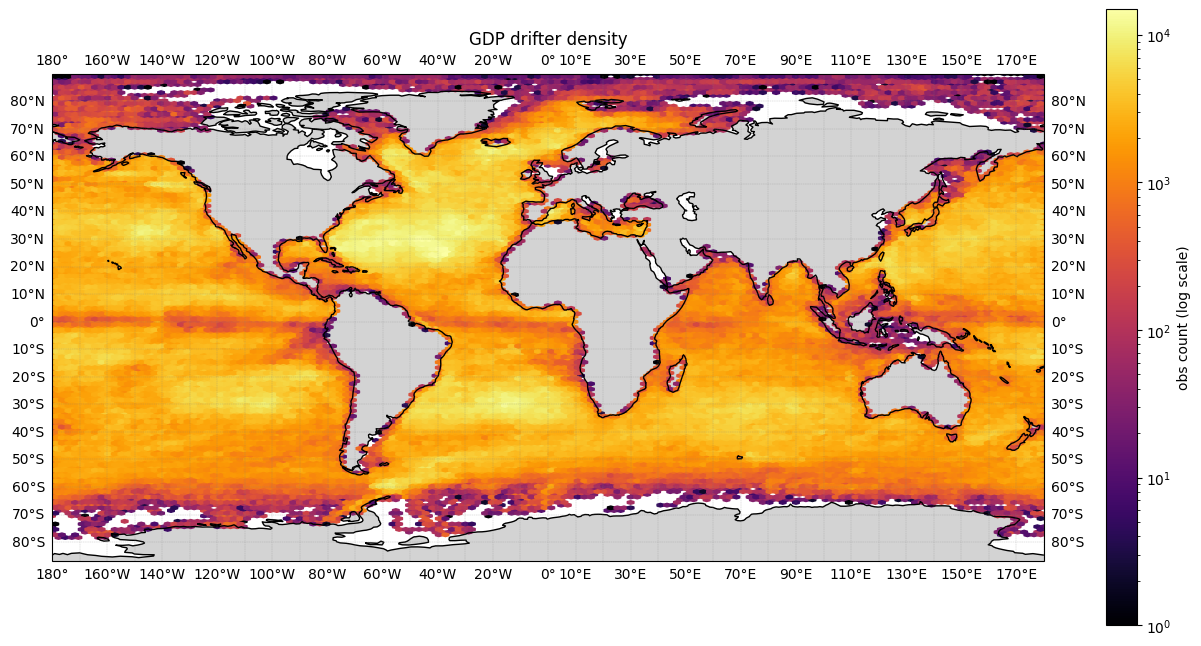

In [29]:
lat = ds['lat'].values.astype(np.float32)
lon = ds['lon'].values.astype(np.float32)

fig = plt.figure(figsize=(16,8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.COASTLINE)
hb = ax.hexbin(lon[::5], lat[::5], gridsize=150, bins='log', cmap='inferno', transform=ccrs.PlateCarree())
plt.colorbar(hb, label='obs count (log scale)')
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--',
                  xlocs=np.arange(-180, 181, 10), ylocs=np.arange(-90, 91, 10))
ax.set_title('GDP drifter density')
plt.show()

**DRIFTER SURFACE CURRENT VELOCITY GLOBAL MAP**

In [30]:
lat = ds['lat'].values.astype(np.float32)
lon = ds['lon'].values.astype(np.float32)
ve = ds['ve'].values.astype(np.float32)
vn = ds['vn'].values.astype(np.float32)

# subsample — mean velocity per cell is stable even with far fewer points than density needs
stride = 5
lat_s, lon_s, ve_s, vn_s = lat[::stride], lon[::stride], ve[::stride], vn[::stride]
del lat, lon, ve, vn
gc.collect()

grid_deg = 2   # 2° cells — coarser than the density map since we need enough points per cell for a stable mean
lat_bins = np.arange(-90, 91, grid_deg)
lon_bins = np.arange(-180, 181, grid_deg)

mean_ve, _, _, _ = binned_statistic_2d(lat_s, lon_s, ve_s, statistic='mean', bins=[lat_bins, lon_bins])
mean_vn, _, _, _ = binned_statistic_2d(lat_s, lon_s, vn_s, statistic='mean', bins=[lat_bins, lon_bins])
count, _, _, _ = binned_statistic_2d(lat_s, lon_s, ve_s, statistic='count', bins=[lat_bins, lon_bins])

# grid cell centers for plotting
lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
LON, LAT = np.meshgrid(lon_centers, lat_centers)

speed = np.sqrt(mean_ve**2 + mean_vn**2)

# mask out cells with too few observations — unreliable mean
min_count = 20
mask = count < min_count
mean_ve_plot = np.where(mask, np.nan, mean_ve)
mean_vn_plot = np.where(mask, np.nan, mean_vn)
speed_plot = np.where(mask, np.nan, speed)

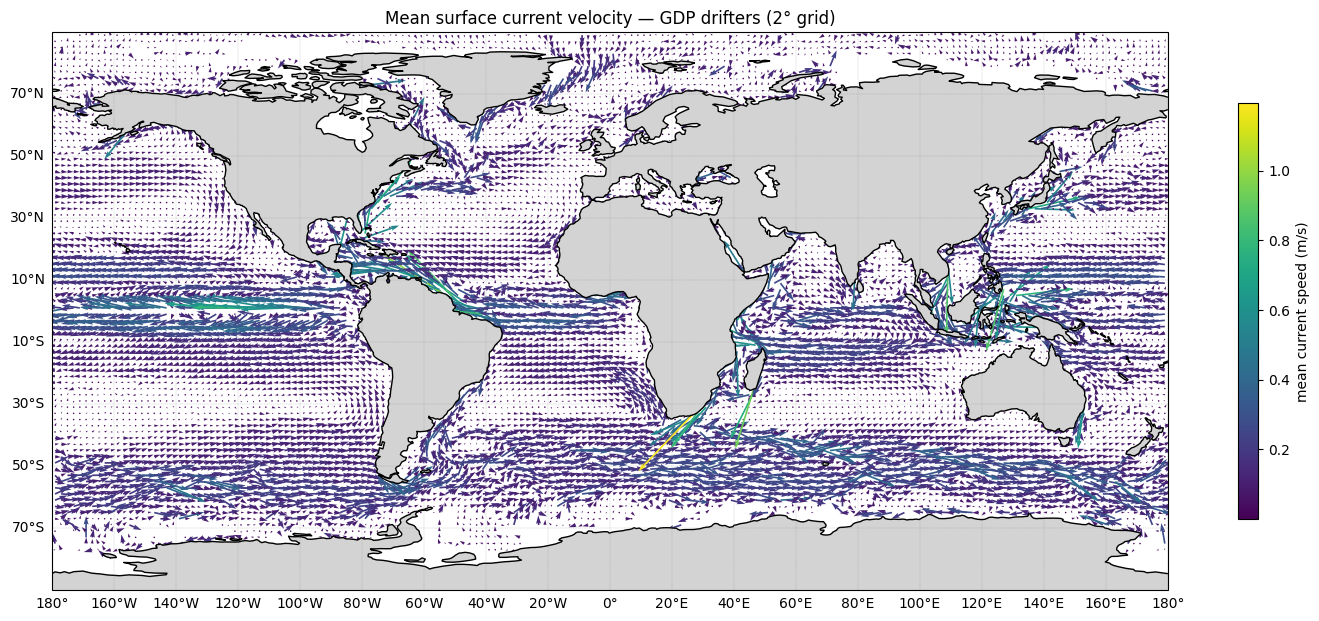

In [31]:
fig = plt.figure(figsize=(18,9))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=2)

# color background by speed, arrows show direction
q = ax.quiver(LON, LAT, mean_ve_plot, mean_vn_plot, speed_plot,
              cmap='viridis', scale=15, width=0.0015, transform=ccrs.PlateCarree())
plt.colorbar(q, label='mean current speed (m/s)', shrink=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--',
                   xlocs=np.arange(-180, 181, 20), ylocs=np.arange(-90, 91, 20))
gl.top_labels = False
gl.right_labels = False

ax.set_title('Mean surface current velocity — GDP drifters (2° grid)')
plt.show()

**MAJOR REGIONS**

![Maritime Shipping Routes](../figures/Map-Passages-with-Shipping-Routes.pdf)

In [9]:
regions = {
    "Gulf Stream": {"lat_min": 30, "lat_max": 50, "lon_min": -80, "lon_max": -50},
    "Kuroshio":    {"lat_min": 15, "lat_max": 40, "lon_min": 115, "lon_max": 145},
    "Agulhas":     {"lat_min": -40, "lat_max": -25, "lon_min": 15, "lon_max": 40},
}

for name, r in regions.items():
    r["lat_bins"] = np.arange(r["lat_min"], r["lat_max"] + 1, 1)
    r["lon_bins"] = np.arange(r["lon_min"], r["lon_max"] + 1, 1)
    r["grid_counts"] = np.zeros((len(r["lat_bins"]) - 1, len(r["lon_bins"]) - 1), dtype=np.int64)  # (lat, lon) order
    r["n_obs"] = 0
    r["traj_indices"] = set()
    r["sum_speed"] = 0.0
    r["sum_speed_sq"] = 0.0
    r["max_speed"] = 0.0
    r["speed_n"] = 0

rowsize = ds["rowsize"].values.astype(np.int64)
id_traj = ds["id"].values
traj_ends = np.cumsum(rowsize)

chunk_size = 500_000
n_obs_total = ds.sizes["obs"]

print("Starting chunked scan...")

for start in range(0, n_obs_total, chunk_size):
    end = min(start + chunk_size, n_obs_total)

    lat = ds["lat"].isel(obs=slice(start, end)).values.astype(np.float32)
    lon = ds["lon"].isel(obs=slice(start, end)).values.astype(np.float32)

    ve = None
    vn = None

    for name, r in regions.items():
        mask = (
            (lat >= r["lat_min"]) & (lat <= r["lat_max"]) &
            (lon >= r["lon_min"]) & (lon <= r["lon_max"])
        )
        current_n = np.count_nonzero(mask)
        r["n_obs"] += current_n
        if current_n == 0:
            continue

        region_lat = lat[mask]
        region_lon = lon[mask]

        H, _, _ = np.histogram2d(region_lat, region_lon, bins=[r["lat_bins"], r["lon_bins"]])
        r["grid_counts"] += H.astype(np.int64)

        local_indices = np.flatnonzero(mask)
        global_indices = local_indices + start
        traj_idx = np.searchsorted(traj_ends, global_indices, side="right")
        r["traj_indices"].update(np.unique(traj_idx).tolist())

        if ve is None:
            ve = ds["ve"].isel(obs=slice(start, end)).values.astype(np.float32)
            vn = ds["vn"].isel(obs=slice(start, end)).values.astype(np.float32)

        speed = np.sqrt(ve[mask]**2 + vn[mask]**2)
        speed = speed[~np.isnan(speed)]
        r["sum_speed"] += speed.sum()
        r["sum_speed_sq"] += (speed**2).sum()
        r["speed_n"] += len(speed)
        if len(speed) > 0:
            r["max_speed"] = max(r["max_speed"], speed.max())

    del lat, lon, ve, vn

    if start == 0 or end % 5_000_000 < chunk_size or end == n_obs_total:
        print(f"Processed {end:,} / {n_obs_total:,} ({end/n_obs_total*100:.1f}%)")

print("SCAN FINISHED")

Starting chunked scan...
Processed 500,000 / 197,214,787 (0.3%)
Processed 5,000,000 / 197,214,787 (2.5%)
Processed 10,000,000 / 197,214,787 (5.1%)
Processed 15,000,000 / 197,214,787 (7.6%)
Processed 20,000,000 / 197,214,787 (10.1%)
Processed 25,000,000 / 197,214,787 (12.7%)
Processed 30,000,000 / 197,214,787 (15.2%)
Processed 35,000,000 / 197,214,787 (17.7%)
Processed 40,000,000 / 197,214,787 (20.3%)
Processed 45,000,000 / 197,214,787 (22.8%)
Processed 50,000,000 / 197,214,787 (25.4%)
Processed 55,000,000 / 197,214,787 (27.9%)
Processed 60,000,000 / 197,214,787 (30.4%)
Processed 65,000,000 / 197,214,787 (33.0%)
Processed 70,000,000 / 197,214,787 (35.5%)
Processed 75,000,000 / 197,214,787 (38.0%)
Processed 80,000,000 / 197,214,787 (40.6%)
Processed 85,000,000 / 197,214,787 (43.1%)
Processed 90,000,000 / 197,214,787 (45.6%)
Processed 95,000,000 / 197,214,787 (48.2%)
Processed 100,000,000 / 197,214,787 (50.7%)
Processed 105,000,000 / 197,214,787 (53.2%)
Processed 110,000,000 / 197,214,787

In [10]:
summary_rows = []
for name, r in regions.items():
    H = r["grid_counts"]
    total_cells = H.size
    occupied_cells = np.count_nonzero(H > 0)
    good_cells = np.count_nonzero(H >= 20)

    mean_speed = r["sum_speed"] / r["speed_n"] if r["speed_n"] > 0 else np.nan
    std_speed = np.sqrt(r["sum_speed_sq"]/r["speed_n"] - mean_speed**2) if r["speed_n"] > 0 else np.nan

    summary_rows.append({
        "Region": name,
        "Total observations": r["n_obs"],
        "Unique drifters": len(r["traj_indices"]),
        "Total 1° cells": total_cells,
        "Occupied cells": occupied_cells,
        "Cells >= 20 obs": good_cells,
        "Spatial coverage %": round(occupied_cells / total_cells * 100, 1),
        "Reliable coverage %": round(good_cells / total_cells * 100, 1),
        "Mean speed (m/s)": round(mean_speed, 3),
        "Std speed (m/s)": round(std_speed, 3),
        "Max speed (m/s)": round(r["max_speed"], 3),
    })

summary = pd.DataFrame(summary_rows).sort_values("Total observations", ascending=False)
summary

,Region,Total observations,Unique drifters,Total 1° cells,Occupied cells,Cells >= 20 obs,Spatial coverage %,Reliable coverage %,Mean speed (m/s),Std speed (m/s),Max speed (m/s)
0,Gulf Stream,5162039,1346,600,441,438,73.5,73.0,0.373,0.300,5.672
1,Kuroshio,4630468,1535,750,622,611,82.9,81.5,0.381,0.256,2.971
2,Agulhas,1413922,667,375,258,257,68.8,68.5,0.503,0.372,2.973


**KUROSHIO CURRENT REGION DRIFTER DENSITY**

In [32]:
lat_min, lat_max = 15, 40
lon_min, lon_max = 115, 145

chunk_size = 5_000_000   # smaller chunks since RAM is tight
n_total = ds.sizes['obs']

lat_list, lon_list, ve_list, vn_list = [], [], [], []

for start in range(0, n_total, chunk_size):
    end = min(start + chunk_size, n_total)

    lat_chunk = ds['lat'].isel(obs=slice(start, end)).values.astype(np.float32)
    lon_chunk = ds['lon'].isel(obs=slice(start, end)).values.astype(np.float32)

    chunk_mask = (lat_chunk >= lat_min) & (lat_chunk <= lat_max) & \
                 (lon_chunk >= lon_min) & (lon_chunk <= lon_max)

    if chunk_mask.any():
        ve_chunk = ds['ve'].isel(obs=slice(start, end)).values.astype(np.float32)
        vn_chunk = ds['vn'].isel(obs=slice(start, end)).values.astype(np.float32)

        lat_list.append(lat_chunk[chunk_mask])
        lon_list.append(lon_chunk[chunk_mask])
        ve_list.append(ve_chunk[chunk_mask])
        vn_list.append(vn_chunk[chunk_mask])
        del ve_chunk, vn_chunk

    del lat_chunk, lon_chunk, chunk_mask

    if (start // chunk_size) % 10 == 0:
        print(f"processed {start:,} / {n_total:,}")

lat_r = np.concatenate(lat_list)
lon_r = np.concatenate(lon_list)
ve_r = np.concatenate(ve_list)
vn_r = np.concatenate(vn_list)
del lat_list, lon_list, ve_list, vn_list
gc.collect()

print(f"n_obs in region: {len(lat_r):,}")

processed 0 / 197,214,787
processed 50,000,000 / 197,214,787
processed 100,000,000 / 197,214,787
processed 150,000,000 / 197,214,787
n_obs in region: 4,620,604


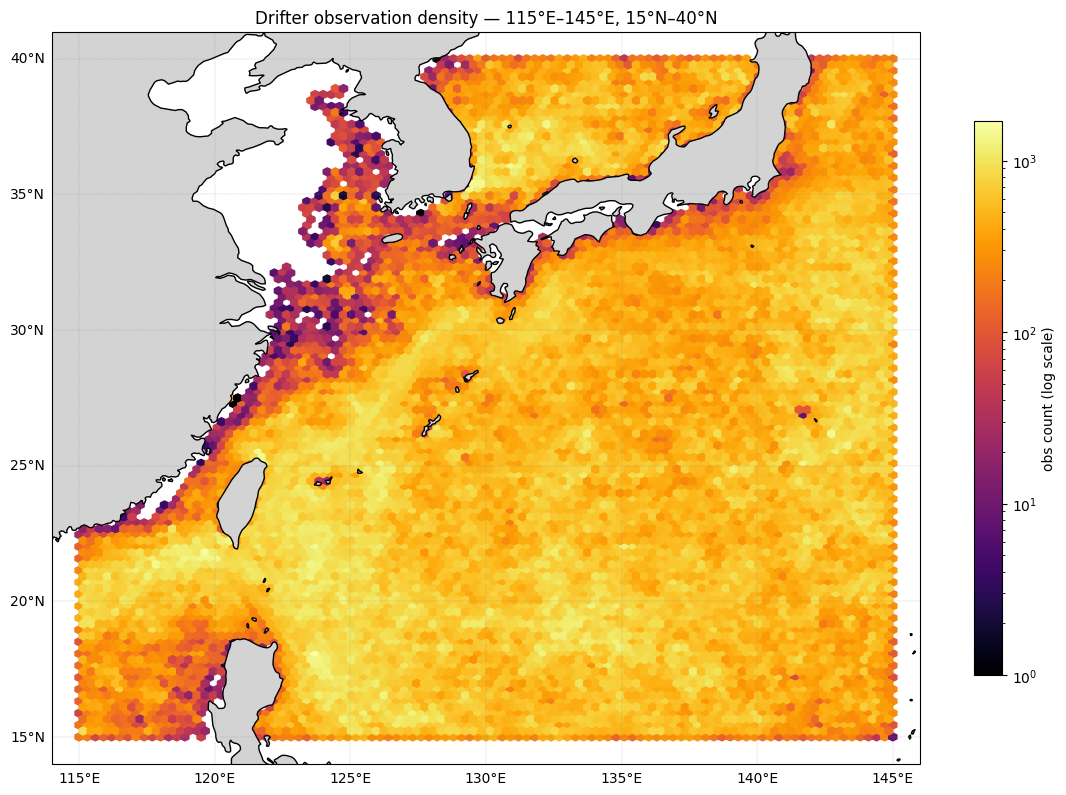

In [33]:
fig = plt.figure(figsize=(14,12))
ax = plt.axes(projection=ccrs.PlateCarree())

pad = 1
ax.set_extent([lon_min - pad, lon_max + pad, lat_min - pad, lat_max + pad], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=2)

hb = ax.hexbin(lon_r, lat_r, gridsize=100, bins='log', cmap='inferno', transform=ccrs.PlateCarree())
plt.colorbar(hb, label='obs count (log scale)', shrink=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--',
                   xlocs=np.arange(lon_min, lon_max+1, 5), ylocs=np.arange(lat_min, lat_max+1, 5))
gl.top_labels = False
gl.right_labels = False

ax.set_title(f'Drifter observation density — {lon_min}°E–{lon_max}°E, {lat_min}°N–{lat_max}°N')
plt.show()

**KUROSHIO CURRENT REGION SURFACE VELOCITY**

In [34]:
grid_deg = 1
lat_bins = np.arange(lat_min, lat_max + grid_deg, grid_deg)
lon_bins = np.arange(lon_min, lon_max + grid_deg, grid_deg)

mean_ve, _, _, _ = binned_statistic_2d(lat_r, lon_r, ve_r, statistic='mean', bins=[lat_bins, lon_bins])
mean_vn, _, _, _ = binned_statistic_2d(lat_r, lon_r, vn_r, statistic='mean', bins=[lat_bins, lon_bins])
count, _, _, _   = binned_statistic_2d(lat_r, lon_r, ve_r, statistic='count', bins=[lat_bins, lon_bins])

lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
lon_centers = (lon_bins[:-1] + lon_bins[1:]) / 2
LON, LAT = np.meshgrid(lon_centers, lat_centers)

speed = np.sqrt(mean_ve**2 + mean_vn**2)

min_count = 20
cell_mask = count < min_count
mean_ve_plot = np.where(cell_mask, np.nan, mean_ve)
mean_vn_plot = np.where(cell_mask, np.nan, mean_vn)
speed_plot   = np.where(cell_mask, np.nan, speed)

print(f"cells with n>=20: {(~cell_mask).sum()} / {cell_mask.size}")

cells with n>=20: 611 / 750


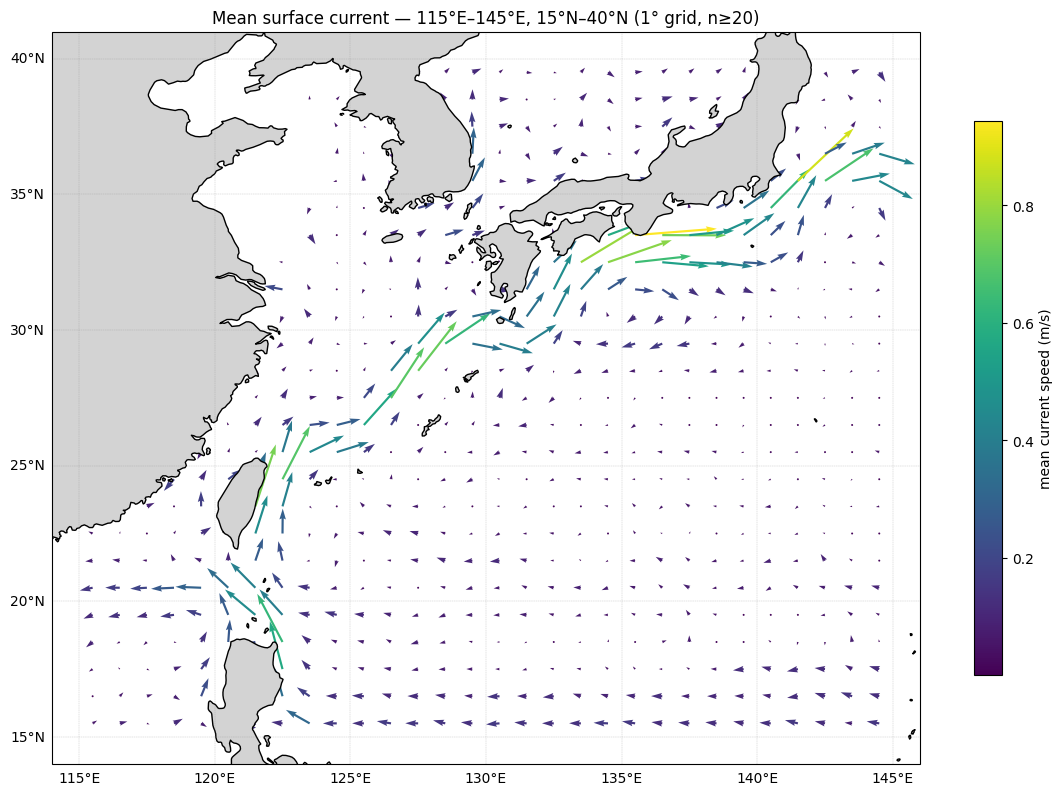

In [35]:
fig = plt.figure(figsize=(14,12))
ax = plt.axes(projection=ccrs.PlateCarree())

pad = 1
ax.set_extent([lon_min - pad, lon_max + pad, lat_min - pad, lat_max + pad], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2)
ax.add_feature(cfeature.COASTLINE, zorder=2)

q = ax.quiver(LON, LAT, mean_ve_plot, mean_vn_plot, speed_plot,
              cmap='viridis', scale=10, width=0.0025, transform=ccrs.PlateCarree())
plt.colorbar(q, label='mean current speed (m/s)', shrink=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--',
                   xlocs=np.arange(lon_min, lon_max+1, 5), ylocs=np.arange(lat_min, lat_max+1, 5))
gl.top_labels = False
gl.right_labels = False

ax.set_title(f'Mean surface current — {lon_min}°E–{lon_max}°E, {lat_min}°N–{lat_max}°N (1° grid, n≥{min_count})')
plt.show()